# Shor's Algorithm — very small circuit demo

We will factor:

$$
N = 15
$$

using:

$$
a = 2.
$$

For this class, focus on the **circuit story**, not the full proof:

1. Hadamards create a counting superposition.
2. Controlled modular multiplication puts **order information into phase**.
3. Inverse QFT turns that phase information into measurable bits.
4. A small classical step recovers the order $r$.
5. `gcd` turns $r$ into factors.

> This is a teaching circuit specialized to `N = 15, a = 2`.  
> It is not a general large-number implementation of Shor.

## 1. What are we actually trying to find?

Look at:

$$
2^x \bmod 15
$$

It repeats:

| x | $2^x \bmod 15$ |
|---|---|
| 0 | 1 |
| 1 | 2 |
| 2 | 4 |
| 3 | 8 |
| 4 | 1 |

So the repetition length — the **order** — is:

$$
\boxed{r=4}
$$

The quantum circuit's main job is to give us information from which we can recover this $r$.

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from fractions import Fraction
from math import gcd

sim = AerSimulator()

N = 15
a = 2

for x in range(5):
    print(f"x={x}:  2^{x} mod 15 = {pow(a, x, N)}")

x=0:  2^0 mod 15 = 1
x=1:  2^1 mod 15 = 2
x=2:  2^2 mod 15 = 4
x=3:  2^3 mod 15 = 8
x=4:  2^4 mod 15 = 1


## 2. Two registers

We use:

- **2 counting qubits** — these will eventually be measured.
- **4 work qubits** — these hold the modular-arithmetic state.

For this tiny example, 2 counting qubits are enough because the order is exactly $4$.

The work register starts in:

$$
|0001\rangle = |1\rangle.
$$

The counting register starts in:

$$
|00\rangle.
$$

## 3. The modular multiplication blocks

Define

$$
U|y\rangle = |2y \bmod 15\rangle.
$$

Then:

$$
U^2|y\rangle = |4y \bmod 15\rangle.
$$

For `N=15`, multiplying by 2 is especially simple in 4-bit binary: it acts like a cyclic shift of the four work bits. That's it -- no arithmetic, just swap gates moving bits along the register.

Below is the actual circuit for $U$ and for $U^2$: real swap gates, drawn directly.

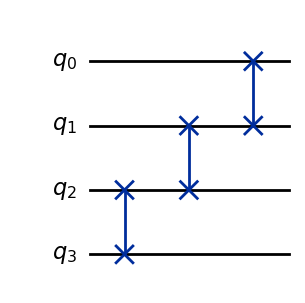

In [2]:
# U : multiply by 2 mod 15 -- this IS the circuit, just swap gates, nothing hidden

U1 = QuantumCircuit(4, name="x2 mod 15")
U1.swap(3, 2)
U1.swap(2, 1)
U1.swap(1, 0)

display(U1.draw(output="mpl"))

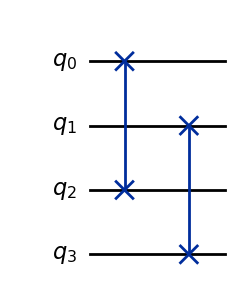

In [3]:
# U^2 : multiply by 4 mod 15 -- again, just swap gates

U2 = QuantumCircuit(4, name="x4 mod 15")
U2.swap(0, 2)
U2.swap(1, 3)

display(U2.draw(output="mpl"))

## 4. Inverse QFT

After the controlled modular operations, useful information is stored in **relative phase**.

We cannot directly read phase with an ordinary computational-basis measurement.

So we use the inverse QFT as a **phase decoder**: swap, then Hadamards with controlled-phase corrections, with negative angles instead of the positive ones from the forward QFT.

Here it is for our 2 counting qubits, built directly, gate by gate:

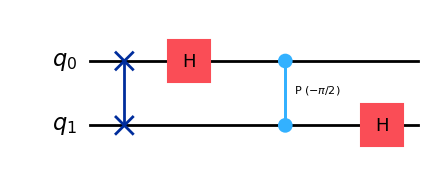

In [4]:
# Inverse QFT on 2 qubits -- built directly with swap, H, and cp gates

IQFT = QuantumCircuit(2, name="QFT_dagger")

IQFT.swap(0, 1)

IQFT.h(0)
IQFT.cp(-np.pi/2, 0, 1)
IQFT.h(1)

display(IQFT.draw(output="mpl"))

## 5. Build the Shor order-finding circuit

Read this circuit from left to right:

### A. Hadamards
Create a superposition on the counting register.

### B. Controlled $U$ and $U^2$
- first counting bit controls $U = \times2 \pmod{15}$
- second counting bit controls $U^2 = \times4 \pmod{15}$

The controls are important: a binary counting bit decides whether that power of $U$ contributes.

### C. Inverse QFT
Convert the accumulated phase information into measurable bits.

### D. Measure
The result is information about the order $r$, **not the factors directly**.

### Building the circuit one stage at a time

Each cell below adds one stage and redraws the circuit so far, the same way we built up the plain QFT circuit qubit by qubit.

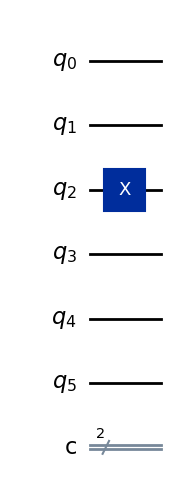

In [5]:
# 2 counting qubits + 4 work qubits + 2 classical bits
qc = QuantumCircuit(6, 2)

count = [0, 1]
work  = [2, 3, 4, 5]

# Work register starts at |0001> = 1
qc.x(work[0])

display(qc.draw(output="mpl"))

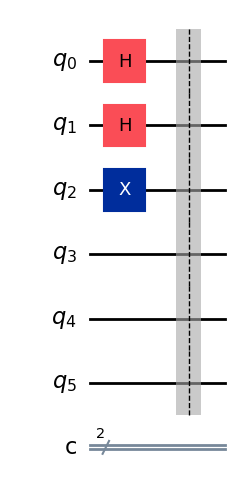

In [6]:
# Stage 1: counting superposition
qc.h(count[0])
qc.h(count[1])
qc.barrier()

display(qc.draw(output="mpl"))

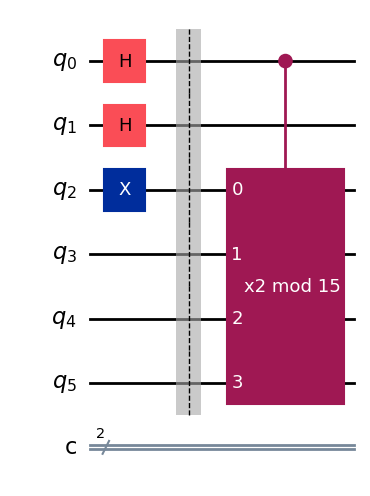

In [7]:
# Stage 2a: qubit 0 controls U (x2 mod 15)
# .to_gate() packages the swap circuit above so it can be controlled and reused
qc.append(U1.to_gate().control(1), [count[0]] + work)

display(qc.draw(output="mpl"))

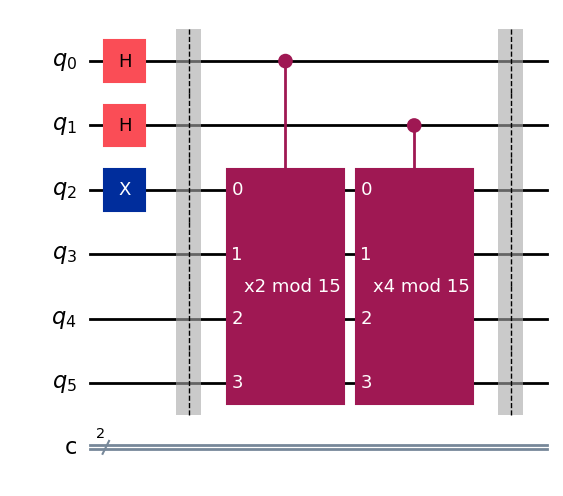

In [8]:
# Stage 2b: qubit 1 controls U^2 (x4 mod 15)
qc.append(U2.to_gate().control(1), [count[1]] + work)
qc.barrier()

display(qc.draw(output="mpl"))

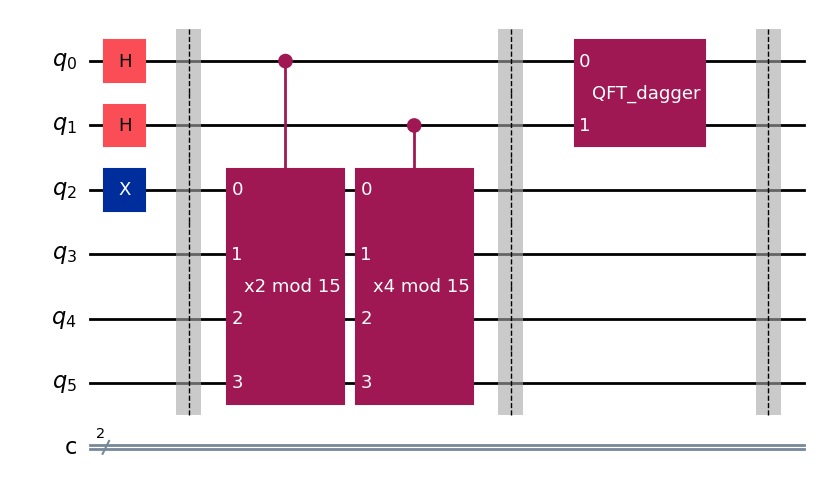

In [9]:
# Stage 3: inverse QFT decodes the phase
qc.append(IQFT.to_gate(), count)
qc.barrier()

display(qc.draw(output="mpl"))

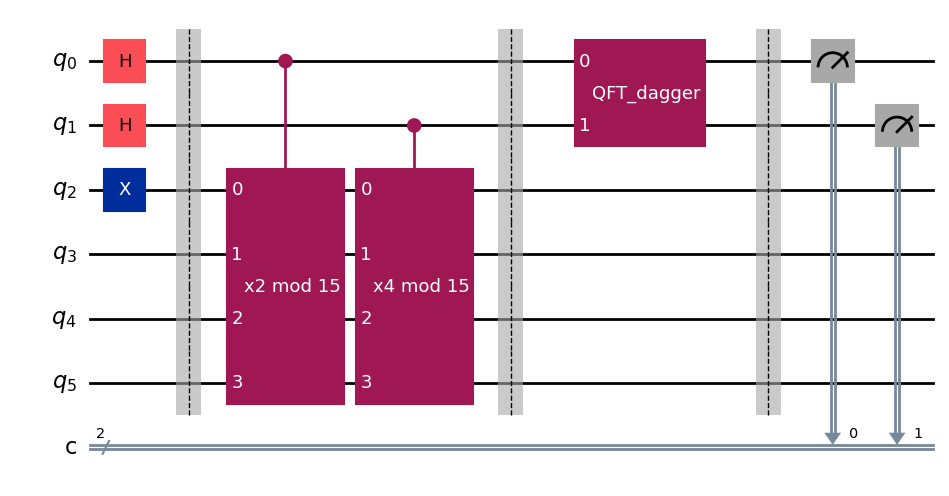

In [10]:
# Stage 4: measure only the counting register
qc.measure(count[0], 0)
qc.measure(count[1], 1)

display(qc.draw(output="mpl"))

{'01': 504, '00': 503, '11': 508, '10': 533}


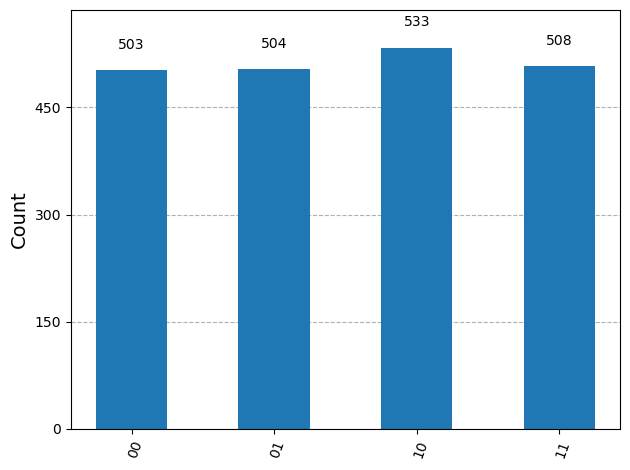

In [12]:
# Run the circuit

counts = sim.run(
    transpile(qc, sim),
    shots=2048
).result().get_counts()

print(counts)
display(plot_histogram(counts))

## 6. How to read the result

For this tiny example you should see outcomes close to:

```text
00, 01, 10, 11
```

Each represents an integer $m$ out of $2^2=4$:

$$
\frac{m}{4}.
$$

So the possible phase samples are:

| measured | fraction |
|---|---|
| `00` | $0/4 = 0$ |
| `01` | $1/4$ |
| `10` | $2/4 = 1/2$ |
| `11` | $3/4$ |

The useful pattern is:

$$
\frac{k}{r}
$$

and here the true order is:

$$
r=4.
$$

A result like $1/4$ or $3/4$ exposes denominator 4 immediately.

`00` is uninformative, and `10` reduces to $1/2$, so in a real run we may need another sample and we verify every candidate order.

In [13]:
# Tiny classical post-processing demo

for measured_integer in [1, 3]:
    fraction = Fraction(measured_integer, 4)
    candidate_r = fraction.denominator

    print(
        f"m={measured_integer}: m/4 = {fraction}, "
        f"candidate r = {candidate_r}, "
        f"check: 2^{candidate_r} mod 15 = {pow(2, candidate_r, 15)}"
    )

m=1: m/4 = 1/4, candidate r = 4, check: 2^4 mod 15 = 1
m=3: m/4 = 3/4, candidate r = 4, check: 2^4 mod 15 = 1


## 7. Turn the order into factors

Once we have:

$$
r=4,
$$

compute:

$$
\gcd(2^{r/2}-1,15)
$$

and

$$
\gcd(2^{r/2}+1,15).
$$

That gives the factors.

The important teaching point is:

> **The quantum circuit does not directly output 3 and 5.**  
> It helps us obtain the order $r$. Classical number theory finishes the job.

In [14]:
r = 4

factor1 = gcd(pow(a, r // 2) - 1, N)
factor2 = gcd(pow(a, r // 2) + 1, N)

print("factor 1 =", factor1)
print("factor 2 =", factor2)
print(f"{N} = {factor1} x {factor2}")

factor 1 = 3
factor 2 = 5
15 = 3 x 5


## What to say while pointing at the circuit

**Hadamards:**  
"These create the counting superposition."

**Controlled modular blocks:**  
"These apply different powers of modular multiplication. Their effect is to encode information about the order into phase."

**Inverse QFT:**  
"We cannot directly read phase, so inverse QFT converts the phase pattern into computational-basis information."

**Measurement:**  
"This gives a sample related to $k/r$, not the factors themselves."

**Classical step:**  
"From the measured fraction we recover a candidate order, verify it, and then use gcd to obtain the factors."

### One-line memory aid

$$
\boxed{
H
\rightarrow
\text{controlled modular powers}
\rightarrow
QFT^{-1}
\rightarrow
\text{measure}
\rightarrow
r
\rightarrow
\gcd
\rightarrow
\text{factors}
}
$$